## 1. Предобработка данных

In [150]:
import pandas as pd
from ydata_profiling import ProfileReport
from phik.report import plot_correlation_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [151]:
RANDOM_STATE = 42
%matplotlib inline

In [152]:
df = pd.read_csv('../data/train.csv', index_col=0)

df.head(3)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.0,2,1.0,0.0,181449.97,0
1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.0,2,1.0,1.0,49503.50,0
2,15694510,Hsueh,678,France,Male,40.0,10,0.0,2,1.0,0.0,184866.69,0


### Убедимся, что пропуски отсутствуют

In [153]:
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Проверим наличие полных дублей и удалим их

In [154]:
print(f"Количество дубликатов: {df.duplicated().sum()}")
df = df.drop_duplicates()

Количество дубликатов: 0


### Удалим идентификаторы (не несут полезной информации для модели)

In [155]:
df = df.drop(columns=['CustomerId', 'Surname'])

### Конвертируем типы данных датасета в более компактные

In [156]:
def apply_conversions(df: pd.DataFrame) -> pd.DataFrame:
    """ Конвертирует категориальные колонки в тип `category` для экономии памяти и ускорения вычислений.
    Числовые колонки с малыми значениями конвертирует в более компактные типы.
    Колонку Gender приведем к числовому типу (0, 1)
    """
    df = df.copy()
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1}).astype('int8')
    
    categ_cols = df.select_dtypes(include='object').columns
    df[categ_cols] = df[categ_cols].astype('category')
    
    micro_cols = ['HasCrCard', 'IsActiveMember', 'Tenure', 'NumOfProducts', 'Age', 'Exited']
    df[micro_cols] = df[micro_cols].astype('int8')
    df['CreditScore'] = df['CreditScore'].astype('int16')
    
    return df
    

In [157]:
df = apply_conversions(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 165034 entries, 0 to 165033
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   CreditScore      165034 non-null  int16   
 1   Geography        165034 non-null  category
 2   Gender           165034 non-null  int8    
 3   Age              165034 non-null  int8    
 4   Tenure           165034 non-null  int8    
 5   Balance          165034 non-null  float64 
 6   NumOfProducts    165034 non-null  int8    
 7   HasCrCard        165034 non-null  int8    
 8   IsActiveMember   165034 non-null  int8    
 9   EstimatedSalary  165034 non-null  float64 
 10  Exited           165034 non-null  int8    
dtypes: category(1), float64(2), int16(1), int8(7)
memory usage: 5.4 MB


In [158]:
print(df.describe(include='category'))
df.describe()


       Geography
count     165034
unique         3
top       France
freq       94215


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,656.454373,0.435571,38.125883,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,80.103340,0.495833,8.867207,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,597.000000,0.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,659.000000,0.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,710.000000,1.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [159]:
X = df.drop(columns=['Exited'])
y = df['Exited']

## 2. Разведочный анализ данных

In [160]:
profile_report = ProfileReport(X, title="Profiling Report", 
                               correlations={
        "pearson": {"calculate": True},
        "spearman": {"calculate": True},
        "kendall": {"calculate": False},   # отключить, если не нужен
        "cramers": {"calculate": True},
        "phi_k": {"calculate": True}
    })
profile_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 263.11it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Посмотрим на корреляции между признаками (без учета целевой переменной)

interval columns not set, guessing: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


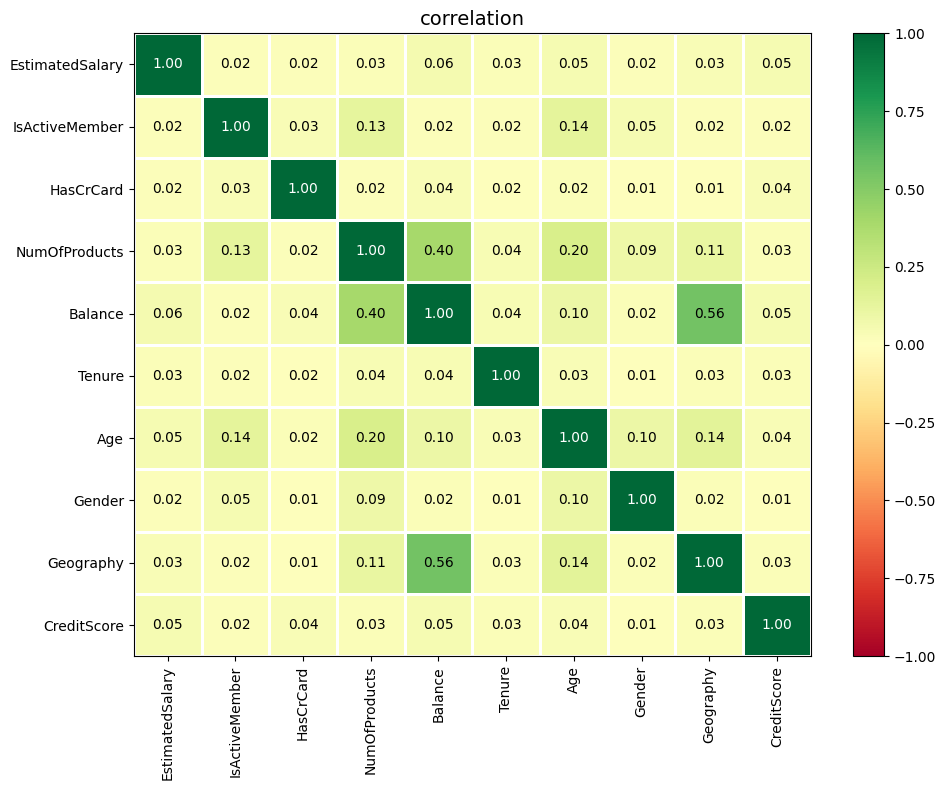

In [161]:
corr_matrix = X.phik_matrix()
plot_correlation_matrix(corr_matrix.values, x_labels=corr_matrix.columns, y_labels=corr_matrix.index, figsize=(10, 8))

Сильные корреляции отсутствуют, есть умереннная корреляция между признаками `Balance` - `Geography`(0.56) и `Balance` - `NumOfProducts` (0.40)

### Оценим распределение таргета

In [165]:
print(df['Exited'].value_counts(normalize=True) * 100)

Exited
0    78.840118
1    21.159882
Name: proportion, dtype: float64


### Выводы:
- 165034 объектов, 10 признаков 
- 5 числовых признаков: `CreditScore`, `Age`, `Tenure`, `EstimatedSalary`, `Balance`
 - 5 категориальных признаков. Бинарные: `IsActiveMember`, `HasCrCard`, `Gender`. С небольшим количеством значений: `NumOfProducts` (значения от 1 до 4), `Geography` (3 страны) применим One-Hot-Encoding
  - дисбаланс классов 1:4 уйдет - не уйдет клиент

### Оценим выбросы для числовых колонок

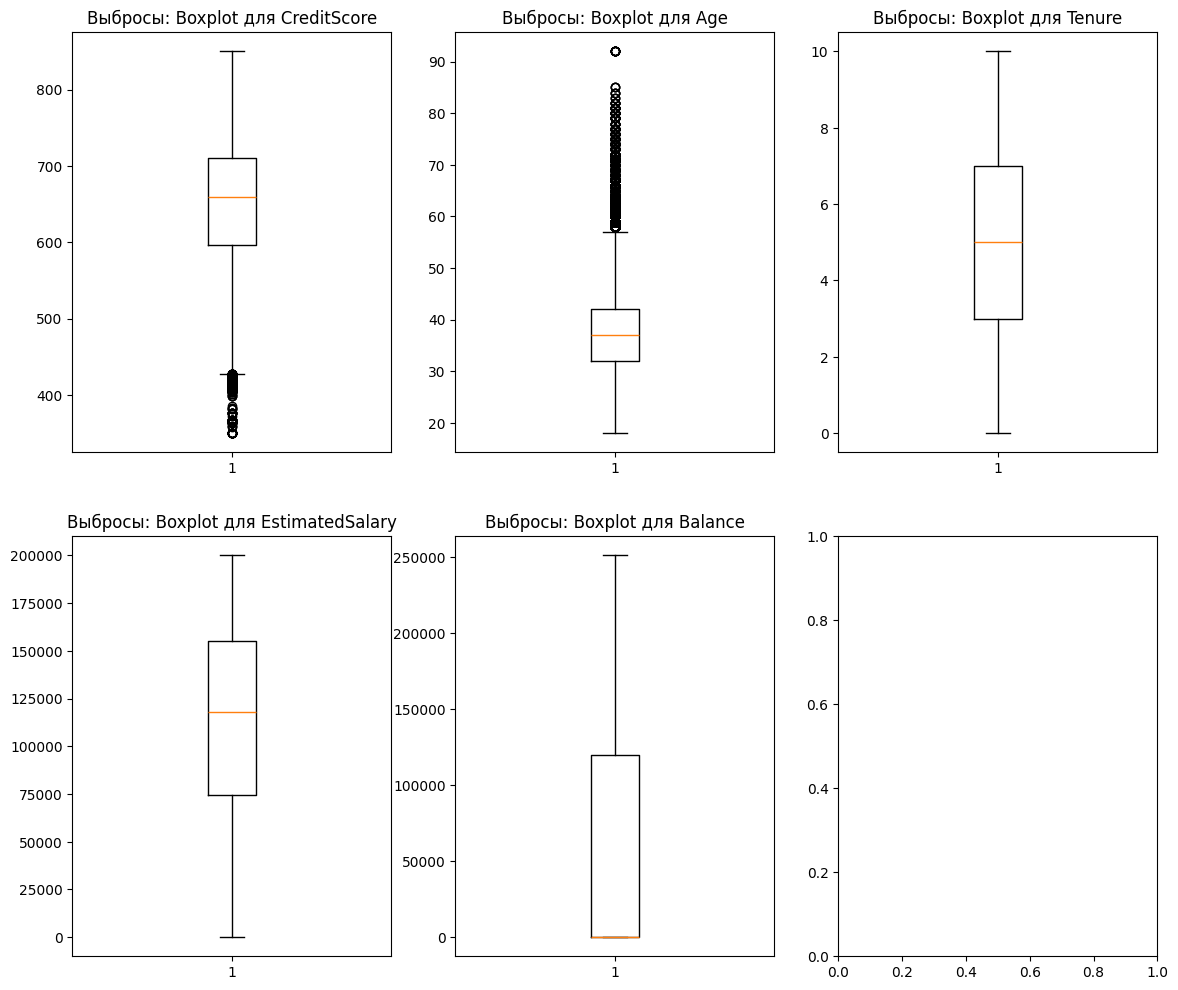

In [162]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'EstimatedSalary', 'Balance']
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(14, 12)) 
ax = ax.ravel()

for i, column in enumerate(num_cols): 
    ax[i].boxplot(X[column])
    ax[i].set_title(f'Выбросы: Boxplot для {column}')
    
plt.show()


По признакам `CreditScore`, `Age` наблюдаются нестандартные отклонения от среднего. Рассмотрим их распределение и статистики


Статистики для CreditScore:
count    165034.000000
mean        656.454373
std          80.103340
min         350.000000
1%          468.000000
5%          524.000000
25%         597.000000
50%         659.000000
75%         710.000000
95%         787.000000
99%         850.000000
max         850.000000
Name: CreditScore, dtype: float64


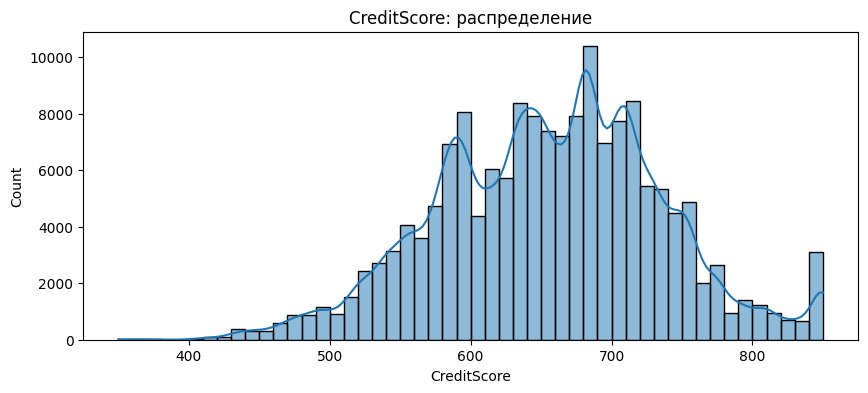

Exited
0    657.590710
1    652.220469
Name: CreditScore, dtype: float64

Статистики для Age:
count    165034.000000
mean         38.125883
std           8.867207
min          18.000000
1%           22.000000
5%           26.000000
25%          32.000000
50%          37.000000
75%          42.000000
95%          56.000000
99%          66.000000
max          92.000000
Name: Age, dtype: float64


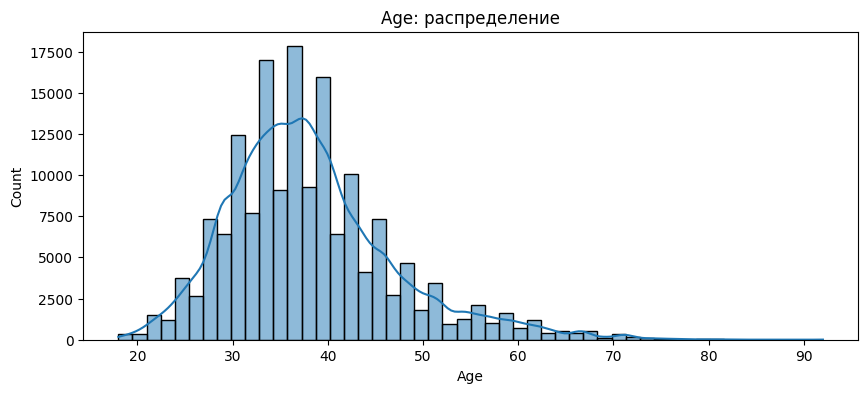

Exited
0    36.560474
1    43.958478
Name: Age, dtype: float64



In [163]:
for feature in ['CreditScore', 'Age']:
    print(f'Статистики для {feature}:')
    print(X[feature].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
    
    plt.figure(figsize=(10, 4))
    sns.histplot(X[feature], bins=50, kde=True)
    plt.title(f'{feature}: распределение')
    plt.xlabel(feature)
    plt.show()
    
    # Проверка: отличается ли средний показатель у ушедших/оставшихся?
    print(df.groupby('Exited')[feature].mean())
    print()

### Распределение остальных числовых признаков

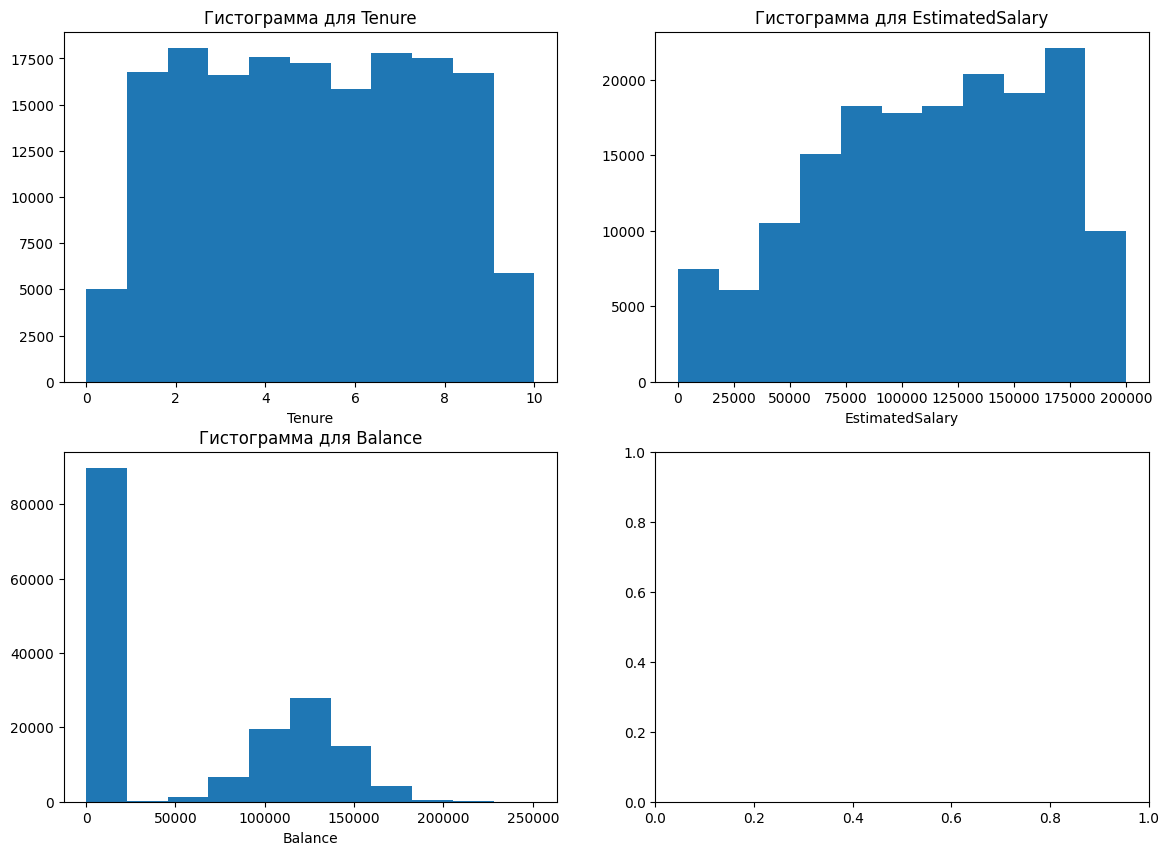

In [167]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 10)) 
ax = ax.ravel()

for i, column in enumerate(['Tenure', 'EstimatedSalary', 'Balance']): 
    ax[i].hist(X[column], bins=11)
    ax[i].set_title(f'Гистограмма для {column}')
    ax[i].set_xlabel(column)
    

### Выводы:
- `CreditScore`, `Age` : гистограммы распределения показали левый и правый хвосты соответственно. Предположим естественные причины наличия таких отклонений: низкий кредитный рейтинг и пожилой возраст клиентов. Это не выбросы. Для линейной модели применим масштабирование
- `Balance` имеет 54.3% нулевых значений (Profile Report), особенность данных, возможно применить флаг `HasBalance`
- `EstimatedSalary` выбросов нет, есть скошенность влево
- `Tenure` (срок измеряется в годах) распределен почти равномерно. Потенциальный кандидат на категориальный признак